<h1>Importing needed frameworks</h1>

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,silhouette_score
from sklearn.decomposition import PCA


<h1>Loading datasets</h1>

In [63]:
obesity_adults = pd.read_csv('data/obesity_adults.csv')
obesity_kids = pd.read_csv('data/obesity_kids.csv')
gdp = pd.read_csv('data/gdp.csv')
food = pd.read_csv('data/food.csv')
sales_2020 = pd.read_csv('data/esales_2020+.csv')
sales_rest = pd.read_csv('data/esales_2020-.csv')
physical_activity = pd.read_csv('data/physical_activity.csv')

<h1>Utils</h1>

In [64]:
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"
target = 'obesity_rate'
features = ['gdp','food_delivery_sales','Alcoholic Beverages','Animal fats',
            'Cereals - Excluding Beer','Fruits - Excluding Wine','Meat','Milk - Excluding Butter','Sugar & Sweeteners','Vegetable Oils']
eu_country_codes = {
    'Austria': 'AUT',
    'Belgium': 'BEL',
    'Bulgaria': 'BGR',
    'Croatia': 'HRV',
    'Cyprus': 'CYP',
    'Czechia': 'CZE',
    'Denmark': 'DNK',
    'Estonia': 'EST',
    'Finland': 'FIN',
    'France': 'FRA',
    'Germany': 'DEU',
    'Greece': 'GRC',
    'Hungary': 'HUN',
    'Ireland': 'IRL',
    'Italy': 'ITA',
    'Latvia': 'LVA',
    'Lithuania': 'LTU',
    'Luxembourg': 'LUX',
    'Malta': 'MLT',
    'Netherlands (Kingdom of the)': 'NLD',
    'Poland': 'POL',
    'Portugal': 'PRT',
    'Romania': 'ROU',
    'Slovakia': 'SVK',
    'Slovenia': 'SVN',
    'Spain': 'ESP',
    'Sweden': 'SWE'
}
iso3_to_iso2 = {
    'AUT': 'AT',
    'BEL': 'BE',
    'BGR': 'BG',
    'HRV': 'HR',
    'CYP': 'CY',
    'CZE': 'CZ',
    'DNK': 'DK',
    'EST': 'EE',
    'FIN': 'FI',
    'FRA': 'FR',
    'DEU': 'DE',
    'GRC': 'GR',
    'HUN': 'HU',
    'IRL': 'IE',
    'ITA': 'IT',
    'LVA': 'LV',
    'LTU': 'LT',
    'LUX': 'LU',
    'MLT': 'MT',
    'NLD': 'NL',
    'POL': 'PL',
    'PRT': 'PT',
    'ROU': 'RO',
    'SVK': 'SK',
    'SVN': 'SI',
    'ESP': 'ES',
    'SWE': 'SE'
}
education_mapping = {
    "ED0-2": "Elementary/Middle",
    "ED3-4": "High school",
    "ED3_4": "High school",
    "ED34_44": "High school",
    "ED35_45": "High school",
    "ED5-8": "College",
}

<h1>Preprocessing and Cleaning Data</h1>

In [65]:

#Cleaning obesity for adults dataset
obesity = pd.concat([obesity_kids,obesity_adults])
obesity = obesity[['GEO_NAME_SHORT','DIM_TIME','DIM_SEX','DIM_AGE','RATE_PER_100_N']].copy()
obesity.columns = ['country','year','sex','age','obesity_rate']
obesity['country'] = obesity['country'].map(eu_country_codes)
obesity = obesity[obesity['country'].notna()]
obesity = obesity[obesity['age'] != 'Y5T19']
obesity

,country,year,sex,age,obesity_rate
9,DEU,1990,FEMALE,Y10T19,5.051622
10,DEU,1990,MALE,Y10T19,4.577196
11,DEU,1990,TOTAL,Y10T19,4.808623
18,GRC,1990,FEMALE,Y10T19,3.037917
19,GRC,1990,MALE,Y10T19,6.050934
...,...,...,...,...,...
20742,MLT,2022,MALE,Y_GE18,35.246661
20743,MLT,2022,TOTAL,Y_GE18,32.287985
20780,NLD,2022,FEMALE,Y_GE18,14.528421
20781,NLD,2022,MALE,Y_GE18,14.537831


In [66]:
physical_activity = physical_activity.rename(columns={'Location':'country','SpatialDimValueCode':'country_code','Period':'year','FactValueNumeric':'inactivity_rate'})
physical_activity = physical_activity[physical_activity['Dim1'] == 'Both sexes']
physical_activity = physical_activity[['country','country_code','year','inactivity_rate']]
physical_activity = physical_activity[physical_activity['country_code'].isin(iso3_to_iso2.keys())]
physical_activity['country_code'] = physical_activity['country_code'].map(iso3_to_iso2)
physical_activity = physical_activity[physical_activity['year'].isin(range(2012,2023))]
physical_activity

,country,country_code,year,inactivity_rate
13,Germany,DE,2022,11.98
18,Denmark,DK,2022,12.14
49,Luxembourg,LU,2022,13.92
57,Latvia,LV,2022,14.49
74,Estonia,EE,2022,15.94
...,...,...,...,...
6279,Belgium,BE,2012,34.85
6350,Cyprus,CY,2012,42.00
6352,Italy,IT,2012,42.06
6379,Portugal,PT,2012,47.54


In [67]:
gdp['Country Code'] = gdp['Country Code'].map(iso3_to_iso2)
gdp = gdp[gdp['Country Code'].isin(iso3_to_iso2.values())]
x = gdp[['Country Code','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022']]
gdp = x.melt(id_vars=["Country Code"],var_name="year",value_name="gdp")
gdp = gdp.rename(columns={'Country Code': 'country_code'})
gdp['year']=gdp['year'].astype(int)
gdp

,country_code,year,gdp
0,AT,2012,61376.720713
1,BE,2012,56356.825129
2,BG,2012,22618.904049
3,CY,2012,39190.382812
4,CZ,2012,39347.049296
...,...,...,...
292,PT,2022,41070.861153
293,RO,2022,39256.988883
294,SK,2022,38664.907695
295,SI,2022,47050.067644


In [68]:
food = food.rename(columns={'Area Code (ISO2)':'country_code','Area':'country','Year':'year'})[['country_code','country','year','Item','Value']]
food = food[food['year'].isin(range(2012,2023))]
food = food.pivot_table(index=["country_code", "country", "year"],columns="Item",values="Value").reset_index()
food

Item,country_code,country,year,Alcoholic Beverages,Animal fats,Cereals - Excluding Beer,Fruits - Excluding Wine,Meat,Milk - Excluding Butter,Sugar & Sweeteners,Vegetable Oils
0,AT,Austria,2012,139.75,26.53,113.65,130.93,87.23,174.22,46.60,16.95
1,AT,Austria,2013,145.02,26.55,113.36,118.97,91.09,171.71,44.90,16.75
2,AT,Austria,2014,141.80,24.75,119.09,122.94,83.41,192.36,45.26,15.56
3,AT,Austria,2015,137.81,24.99,115.99,118.34,88.59,191.44,47.09,15.58
4,AT,Austria,2016,131.08,25.81,116.35,105.15,85.87,200.78,48.51,15.30
...,...,...,...,...,...,...,...,...,...,...,...
303,SK,Slovakia,2018,86.63,22.36,114.95,62.16,58.13,242.51,84.05,12.99
304,SK,Slovakia,2019,79.84,26.66,128.48,62.44,62.00,210.00,81.83,16.05
305,SK,Slovakia,2020,84.18,28.75,132.56,65.88,62.17,199.97,73.74,14.30
306,SK,Slovakia,2021,79.08,31.26,131.36,68.02,63.58,198.09,62.71,12.65


In [69]:
sales_rest = sales_rest.rename(columns={"geo":'country','TIME_PERIOD':'year','OBS_VALUE':'food_delivery_sales'})
sales_2020 = sales_2020.rename(columns={"geo":'country','TIME_PERIOD':'year','OBS_VALUE':'food_delivery_sales'})

sales_2020['country'] = sales_2020['country'].replace({"EL":"GR"})
sales_rest['country'] = sales_rest['country'].replace({"EL":"GR"})

sales_before_2020 = sales_rest[(sales_rest['indic_is'] == 'I_BFOOD') &(sales_rest['ind_type'] == 'IND_TOTAL') &
    (
        (sales_rest['country'].isin(iso3_to_iso2.values())) |
        (sales_rest['country'] == 'EU27_2020')
    ) & (sales_rest['year'].isin(range(2012, 2020)))]

sales_after_2020 = (
    sales_2020[(sales_2020['indic_is'].isin(['I_BFDS','I_BFDR'])) &(sales_2020['year'].isin(range(2020, 2023))) &
        (
            (sales_2020['country'].isin(iso3_to_iso2.values())) |
            (sales_2020['country'] == 'EU27_2020')
        )].groupby(['country','year'], as_index=False)['food_delivery_sales'].sum()
)

cols = ['country', 'year', 'food_delivery_sales']
sales_before_2020 = sales_before_2020[cols]
sales_after_2020 = sales_after_2020[cols]
sales = pd.concat([sales_before_2020, sales_after_2020], ignore_index=True)
sales


,country,year,food_delivery_sales
0,AT,2012,5.64
1,AT,2013,5.97
2,AT,2014,7.08
3,AT,2015,8.89
4,AT,2016,10.56
...,...,...,...
302,SI,2021,21.40
303,SI,2022,15.39
304,SK,2020,17.03
305,SK,2021,29.11


In [70]:
gdp_obesity_2012_2022 = gdp
temp = obesity[(obesity['sex'] == 'TOTAL') & (obesity['age'] == 'Y_GE18') & (obesity['year'].isin(range(2012,2023)))] # 297
temp['country'] =temp['country'].map(iso3_to_iso2)
temp = temp.rename(columns={'country':'country_code'})
gdp_obesity_2012_2022 = gdp_obesity_2012_2022.merge(temp,on=['country_code', 'year'],how='inner')
gdp_obesity_2012_2022


,country_code,year,gdp,sex,age,obesity_rate
0,AT,2012,61376.720713,TOTAL,Y_GE18,14.165790
1,BE,2012,56356.825129,TOTAL,Y_GE18,17.820251
2,BG,2012,22618.904049,TOTAL,Y_GE18,17.646722
3,CY,2012,39190.382812,TOTAL,Y_GE18,21.558790
4,CZ,2012,39347.049296,TOTAL,Y_GE18,21.837513
...,...,...,...,...,...,...
292,PT,2022,41070.861153,TOTAL,Y_GE18,21.791112
293,RO,2022,39256.988883,TOTAL,Y_GE18,34.039709
294,SK,2022,38664.907695,TOTAL,Y_GE18,26.824254
295,SI,2022,47050.067644,TOTAL,Y_GE18,19.441810


In [71]:
dataset = gdp_obesity_2012_2022.merge(food,on=['country_code','year'],how='inner')
dataset = dataset.merge(sales.rename(columns={'country':'country_code'}),on=['country_code','year'],how='inner')
dataset = dataset.merge(physical_activity,on=['country_code','year'],how='inner')
numeric_cols = dataset.select_dtypes(include='number').columns
dataset

,country_code,year,gdp,sex,age,obesity_rate,country_x,Alcoholic Beverages,Animal fats,Cereals - Excluding Beer,Fruits - Excluding Wine,Meat,Milk - Excluding Butter,Sugar & Sweeteners,Vegetable Oils,food_delivery_sales,country_y,inactivity_rate
0,AT,2012,61376.720713,TOTAL,Y_GE18,14.165790,Austria,139.75,26.53,113.65,130.93,87.23,174.22,46.60,16.95,5.64,Austria,25.51
1,BE,2012,56356.825129,TOTAL,Y_GE18,17.820251,Belgium,109.53,27.50,154.92,53.90,72.08,173.50,53.82,10.37,4.49,Belgium,34.85
2,BG,2012,22618.904049,TOTAL,Y_GE18,17.646722,Bulgaria,93.06,5.08,159.75,53.77,54.01,138.87,29.49,9.37,1.03,Bulgaria,26.24
3,CY,2012,39190.382812,TOTAL,Y_GE18,21.558790,Cyprus,57.63,1.58,161.84,66.94,78.75,159.62,58.17,13.78,0.67,Cyprus,42.00
4,CZ,2012,39347.049296,TOTAL,Y_GE18,21.837513,Czechia,162.89,14.05,117.71,61.33,76.01,138.06,65.96,17.74,0.96,Czechia,23.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PT,2022,41070.861153,TOTAL,Y_GE18,21.791112,Portugal,123.37,12.64,159.16,131.73,96.74,238.51,28.13,15.03,26.26,Portugal,51.65
292,RO,2022,39256.988883,TOTAL,Y_GE18,34.039709,Romania,116.60,7.74,186.77,100.40,71.00,223.97,30.48,19.04,13.82,Romania,36.76
293,SK,2022,38664.907695,TOTAL,Y_GE18,26.824254,Slovakia,89.25,30.38,122.42,64.47,65.45,253.22,58.20,13.30,22.82,Slovakia,23.30
294,SI,2022,47050.067644,TOTAL,Y_GE18,19.441810,Slovenia,96.40,12.98,170.52,129.92,62.34,206.58,51.25,7.23,15.39,Slovenia,18.97


<h1>Obesity Map<h1>

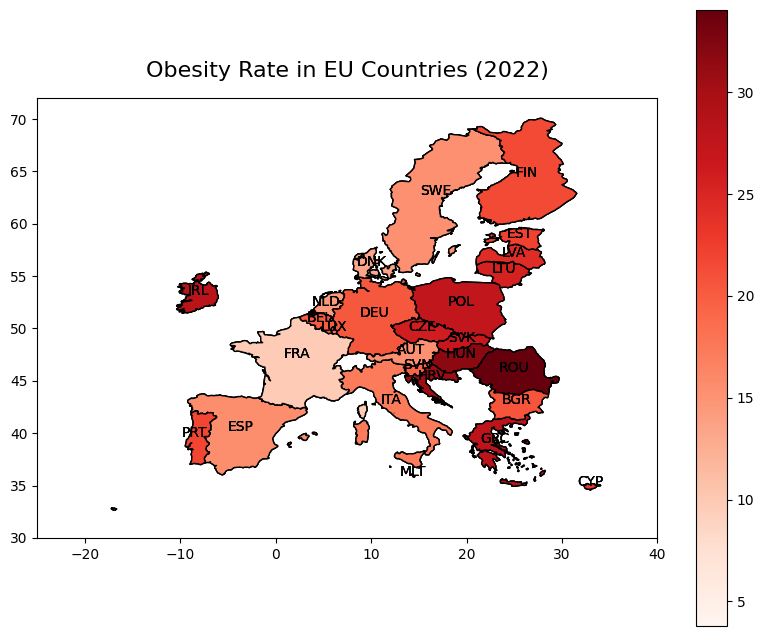

In [72]:

#Preparing the used data and map
data = obesity[(obesity['sex'] == 'TOTAL') & (obesity['year'] == 2022)]
world = gpd.read_file(url)
world.loc[(world['SOV_A3'] == 'FR1') & (world['NAME'] == 'France'),'SOV_A3'] = 'FRA'
world.loc[(world['SOV_A3'] == 'FI1') & (world['NAME'] == 'Finland'),'SOV_A3'] = 'FIN'
world.loc[(world['SOV_A3'] == 'NL1') & (world['NAME'] == 'Netherlands'),'SOV_A3'] = 'NLD'
world.loc[(world['SOV_A3'] == 'DN1') & (world['NAME'] == 'Denmark'),'SOV_A3'] = 'DNK'
eu_map = world[world['SOV_A3'].isin(data['country'])]
#Filtering non-EU countries out

merged = eu_map.merge(data,left_on='SOV_A3',right_on='country',how='left')
figure, axis = plt.subplots(figsize=(10, 8))
merged.plot(column='obesity_rate',cmap='Reds',legend=True,edgecolor='black',linewidth=1,ax=axis)

axis.set_xlim(-25, 40)
axis.set_ylim(30, 72)

# Labels
axis.set_title('Obesity Rate in EU Countries (2022)', fontsize=16, pad=15)
for idx, row in merged.iterrows():
    axis.text(
        row.geometry.centroid.x + 5 if row['SOV_A3'] == 'FRA' else row.geometry.centroid.x,
        row.geometry.centroid.y + 5 if row['SOV_A3'] == 'FRA' else row.geometry.centroid.y,
        row['SOV_A3'],fontsize=10,ha='center'
    )

<h1>Analysis Obesity and sex accross EU countries</h1>

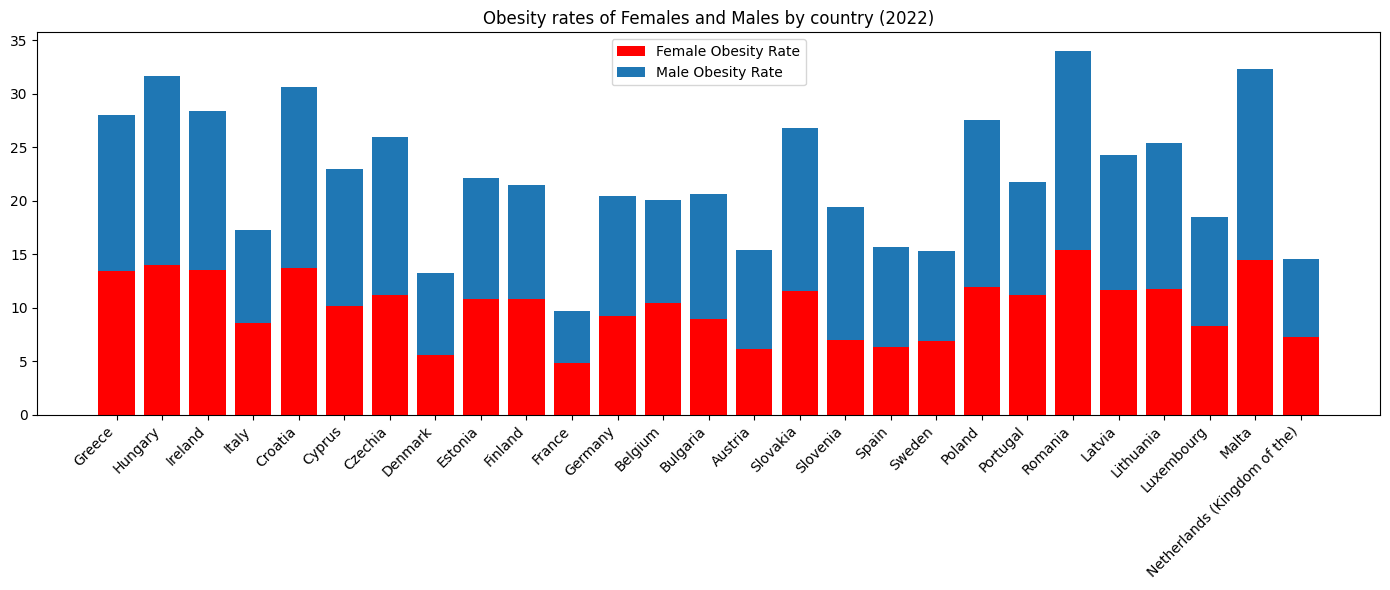

In [73]:
female_obesity = obesity[(obesity['sex'] == 'FEMALE') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]
male_obesity = obesity[(obesity['sex'] == 'MALE') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]
total = obesity[(obesity['sex'] == 'TOTAL') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]

df = pd.merge(female_obesity[['country','obesity_rate']],male_obesity[['country','obesity_rate']],on='country',suffixes=('_females','_males'))
df = df.merge(total[['country','obesity_rate']],on='country')
df = df.rename(columns={'obesity_rate':'obesity_rate_total'})
scaler = df['obesity_rate_total'] / (df['obesity_rate_females'] + df['obesity_rate_males'])
df['obesity_female_scaled'] = df['obesity_rate_females'] * scaler
df['obesity_male_scaled'] = df['obesity_rate_males'] * scaler
df['country'] = df['country'].map({v:k for k,v in eu_country_codes.items()})

plt.figure(figsize=(14,6))
plt.bar(df['country'],df['obesity_female_scaled'],label='Female Obesity Rate',color='red')
plt.bar(df['country'],df['obesity_male_scaled'],bottom=df['obesity_female_scaled'],label='Male Obesity Rate')
plt.title('Obesity rates of Females and Males by country (2022)')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.legend()
plt.show()


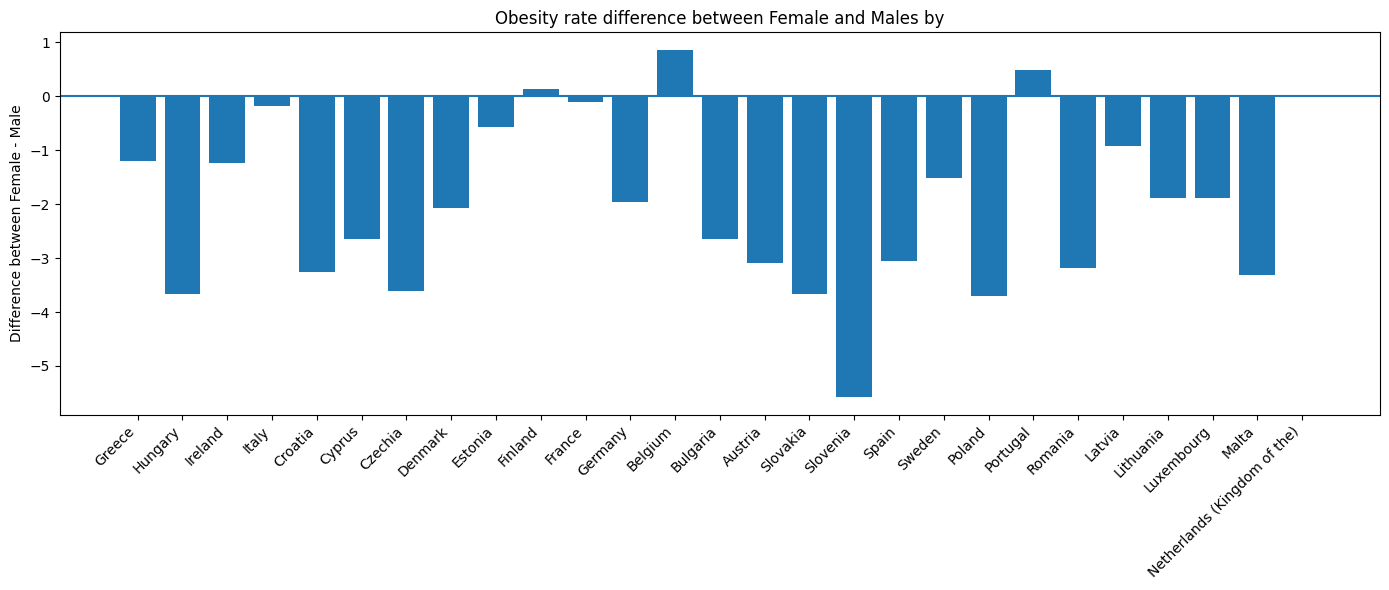

In [74]:
df['obesity_diff'] = df['obesity_female_scaled'] - df['obesity_male_scaled']
df
plt.figure(figsize=(14,6))
plt.bar(df['country'],df['obesity_diff'])
plt.axhline(0)
plt.xticks(rotation=45,ha='right')
plt.ylabel('Difference between Female - Male')
plt.title('Obesity rate difference between Female and Males by')
plt.tight_layout()
plt.show()

<h1>Obesity and GPD Analysis</h1>

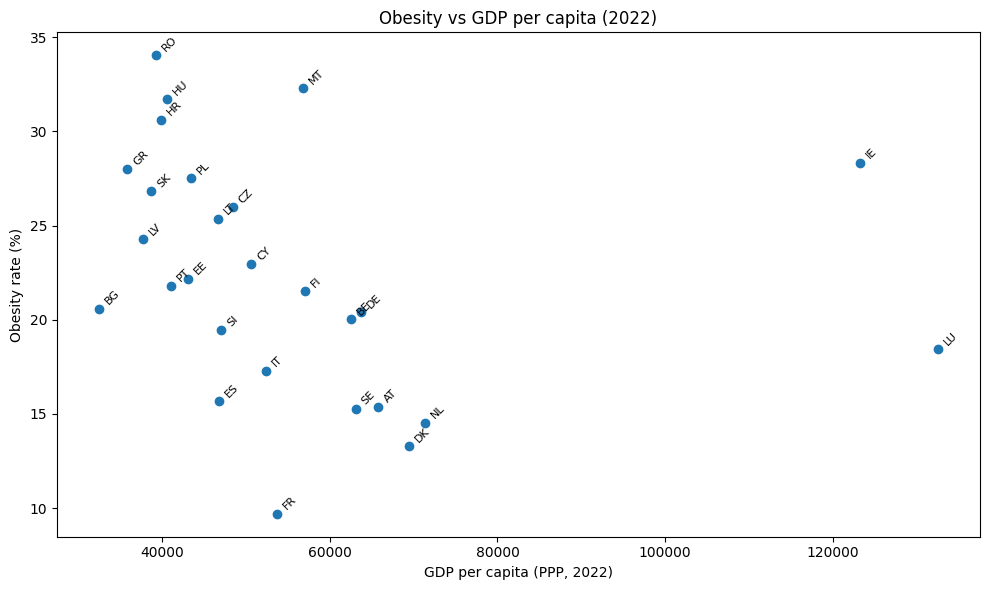

In [75]:
data = gdp_obesity_2012_2022[(gdp_obesity_2012_2022['year'] == 2022)]

plt.figure(figsize=(10,6))
plt.scatter(data["gdp"], data['obesity_rate'])
plt.xlabel("GDP per capita (PPP, 2022)")
plt.ylabel("Obesity rate (%)")
plt.title("Obesity vs GDP per capita (2022)")

# Labels
for i, text in enumerate(data["country_code"]):
    plt.annotate(
        text,(data["gdp"].iloc[i], data["obesity_rate"].iloc[i]),textcoords="offset points",
        xytext=(3,3),rotation=45,fontsize=8
    )
    
plt.tight_layout()
plt.show()

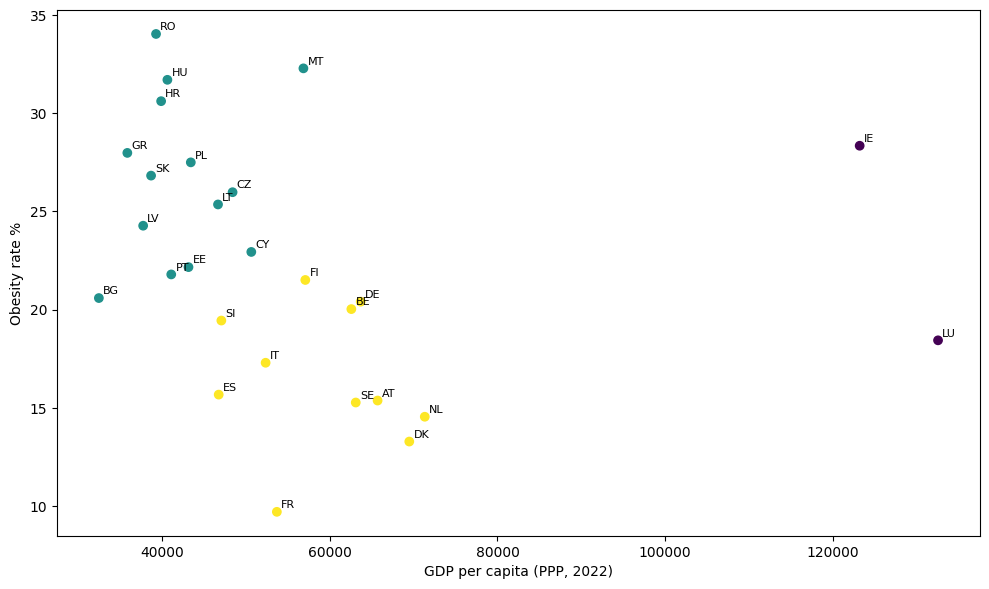

In [76]:
X = data[["gdp", "obesity_rate"]].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
best_score = -np.inf
best_k = None
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
y_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(data["gdp"],data["obesity_rate"],c=y_labels)

for i, txt in enumerate(data["country_code"]):
    plt.annotate(txt,(data["gdp"].iloc[i], data["obesity_rate"].iloc[i]),textcoords="offset points",xytext=(3,3),fontsize=8)

plt.xlabel("GDP per capita (PPP, 2022)")
plt.ylabel("Obesity rate %")

plt.tight_layout()
plt.show()

<h1>Analysis of obesity and food</h1>

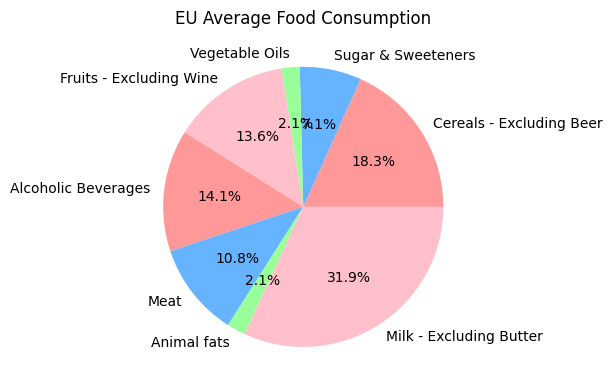

In [77]:
food_items = ['Cereals - Excluding Beer','Sugar & Sweeteners','Vegetable Oils',  'Fruits - Excluding Wine', 
              'Alcoholic Beverages','Meat','Animal fats',  'Milk - Excluding Butter']

colors = ['#ff9999', '#66b3ff', '#99ff99', 'pink'] 
explode = (0.05, 0.05, 0.05, 0.05)

plt.figure(figsize=(6,8))
plt.pie(food[food['year'] == 2022][food_items].median(),labels=food_items,autopct='%1.1f%%',colors=colors,)
plt.title("EU Average Food Consumption")
plt.tight_layout()
plt.show()


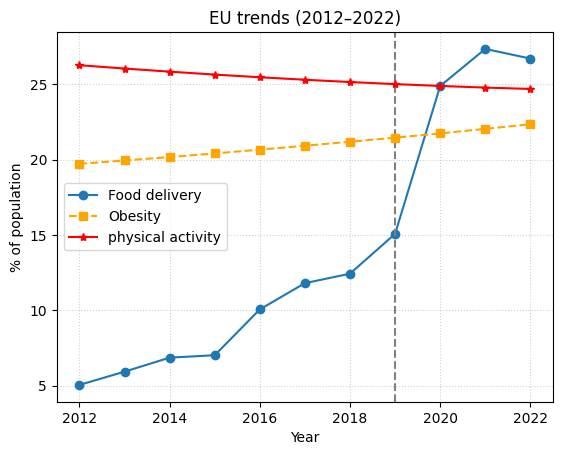

In [78]:

eu_obesity = (
    obesity[
        (obesity['sex'] == 'TOTAL') &
        (obesity['age'] == 'Y_GE18') &
        (obesity['year'].between(2012, 2023))
    ]
    .groupby('year')['obesity_rate'].mean().reset_index()
)

eu_physical_activity = physical_activity.groupby('year')['inactivity_rate'].mean().reset_index()
sales_df = sales[(sales['country'] == 'EU27_2020') & (sales['year'].isin(range(2012,2023)))]


fig, ax1 = plt.subplots()

ax1.plot(sales_df['year'], sales_df['food_delivery_sales'], marker='o', label='Food delivery')
ax1.axvline(x=2019, linestyle='--',color='grey')
ax1.plot(eu_obesity['year'], eu_obesity['obesity_rate'], marker='s', linestyle='--', label='Obesity', color='orange')
ax1.plot(eu_physical_activity['year'],eu_physical_activity['inactivity_rate'],marker='*', linestyle='-', label='physical activity', color='red')
ax1.plot()
ax1.set_ylabel('% of population')
ax1.set_xlabel("Year")
ax1.set_title("EU trends (2012–2022)")
ax1.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [79]:
X = dataset[features]
y = dataset[target]
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)


R²: 0.841287819359001
RMSE: 2.0328911427302727


In [80]:
corr = X.corr()
sorted_corr = corr.unstack().sort_values(ascending=False)
res = sorted_corr[sorted_corr < 1].drop_duplicates().head(10)
res

gdp                      Sugar & Sweeteners         0.657076
                         Fruits - Excluding Wine    0.609876
Milk - Excluding Butter  gdp                        0.370707
gdp                      Alcoholic Beverages        0.369173
food_delivery_sales      Milk - Excluding Butter    0.361786
                         gdp                        0.361004
Alcoholic Beverages      Sugar & Sweeteners         0.359384
Milk - Excluding Butter  Fruits - Excluding Wine    0.352802
Meat                     gdp                        0.289812
                         Alcoholic Beverages        0.237199
dtype: float64

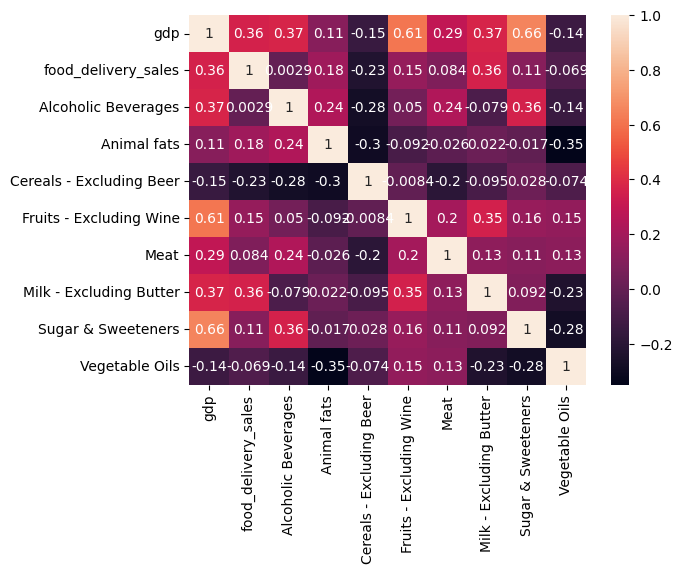

In [81]:
sns.heatmap(corr,annot=True)
plt.show()

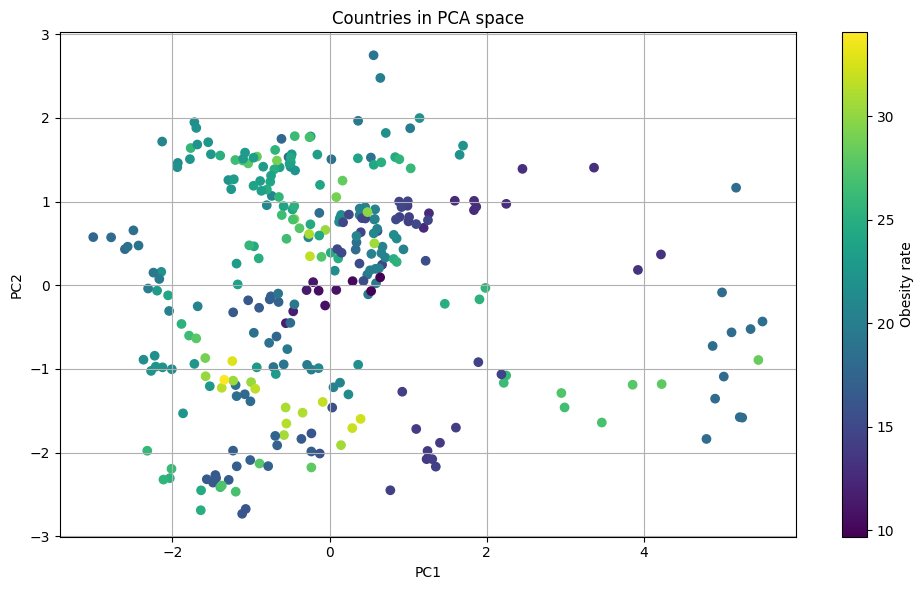

In [95]:
X = dataset[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
dataset['PC1'] = X_pca[:, 0]
dataset['PC2'] = X_pca[:, 1]
plt.figure(figsize=(10, 6))
plt.scatter(dataset['PC1'], dataset['PC2'], c=dataset['obesity_rate'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Countries in PCA space')
plt.colorbar(label='Obesity rate')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
vars = pd.DataFrame(pca.components_.T,columns=['PC1', 'PC2'],index=features)

print("\nTop contributors to PC1:")
print(vars['PC1'].sort_values(ascending=False))

print("\nTop contributors to PC2:")
print(vars['PC2'].sort_values(ascending=False))


Top contributors to PC1:
gdp                         0.550535
Sugar & Sweeteners          0.382455
Fruits - Excluding Wine     0.340990
Milk - Excluding Butter     0.316448
food_delivery_sales         0.302993
Alcoholic Beverages         0.298819
Meat                        0.247118
Animal fats                 0.157248
Vegetable Oils             -0.165385
Cereals - Excluding Beer   -0.199952
Name: PC1, dtype: float64

Top contributors to PC2:
Animal fats                 0.570970
Alcoholic Beverages         0.326924
Sugar & Sweeteners          0.050682
food_delivery_sales         0.001346
gdp                        -0.136301
Meat                       -0.160864
Milk - Excluding Butter    -0.190724
Cereals - Excluding Beer   -0.256738
Vegetable Oils             -0.450684
Fruits - Excluding Wine    -0.463338
Name: PC2, dtype: float64


<Figure size 2000x1900 with 0 Axes>

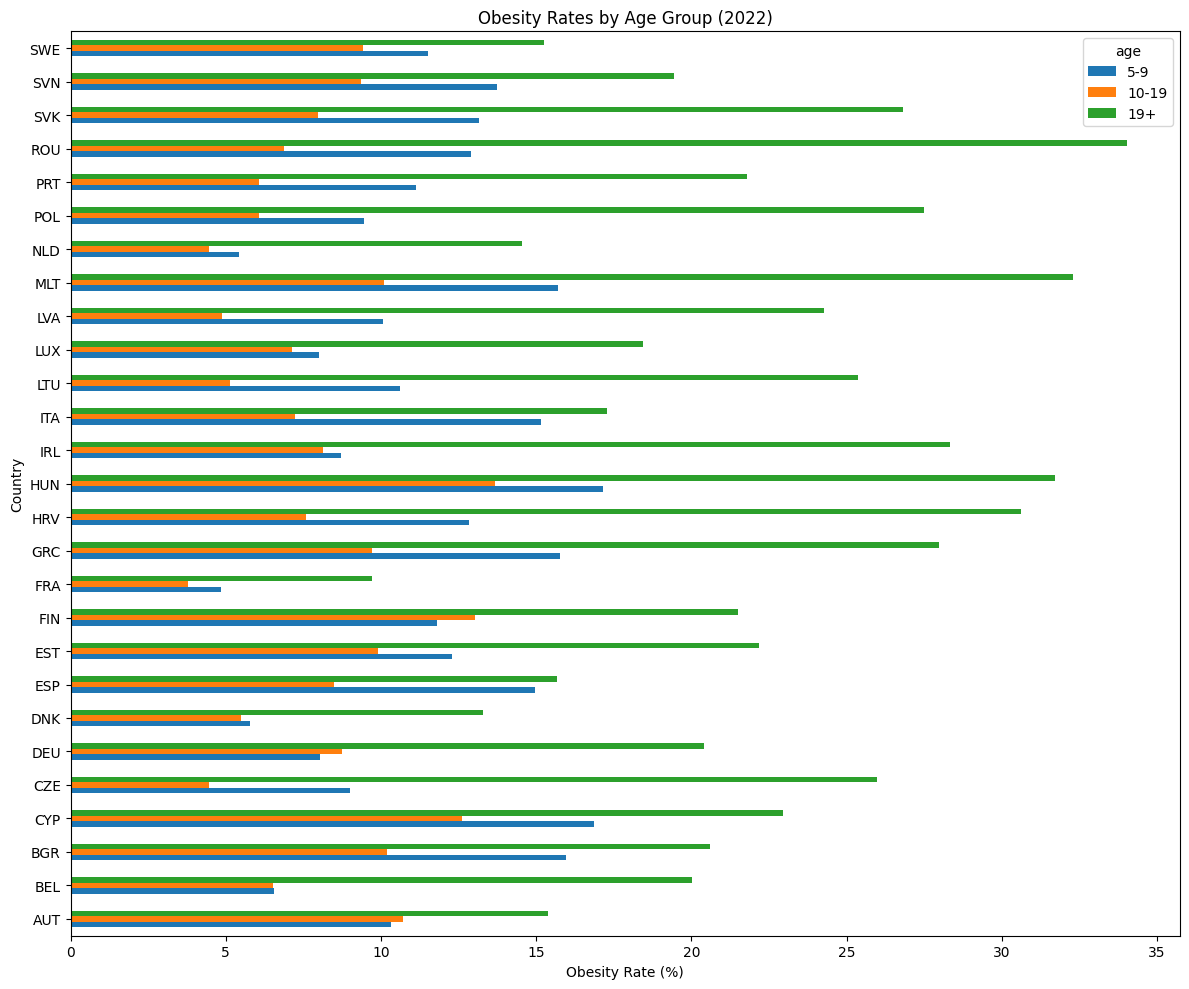

In [82]:
df = obesity.pivot_table(
    index=['country', 'year', 'sex'],
    columns='age',
    values='obesity_rate'
).reset_index()
df['5-9'] = df['Y5T9']
df['10-19'] = df['Y10T19']
df['19+'] = df['Y_GE18']
plot_df = df[(df['sex'] == 'TOTAL') & (df['year'] == 2022)]
plot_df = plot_df.set_index('country')
plt.figure(figsize=(20, 19))
plot_df[['5-9', '10-19', '19+']].plot(
    kind='barh',
    figsize=(12, 10)
)
plt.title('Obesity Rates by Age Group (2022)')
plt.ylabel('Country')
plt.xlabel('Obesity Rate (%)')

plt.tight_layout()
plt.show()